In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

## Preprocessing


### Normalize


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

### Reshape


In [ ]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

### Check


In [5]:
print(x_train.shape)

(60000, 28, 28, 1)


## Experiment 1 — Adam Optimizer


In [ ]:
model_adam = models.Sequential(
    [
        layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),
    ]
)

c:\Users\besho\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile


In [ ]:
model_adam.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# Training


In [ ]:
history_adam = model_adam.fit(
    x_train, y_train, epochs=10, validation_split=0.2, batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9262 - loss: 0.2405 - val_accuracy: 0.9831 - val_loss: 0.0551
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9739 - loss: 0.0853 - val_accuracy: 0.9879 - val_loss: 0.0437
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9809 - loss: 0.0629 - val_accuracy: 0.9893 - val_loss: 0.0367
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9845 - loss: 0.0507 - val_accuracy: 0.9878 - val_loss: 0.0444
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9875 - loss: 0.0410 - val_accuracy: 0.9901 - val_loss: 0.0343
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9889 - loss: 0.0349 - val_accuracy: 0.9904 - val_loss: 0.0396
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9898 - loss: 0.0339 - val_accuracy: 0.9921 - val_loss: 0.0354
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9913 -

## Evaluate Model


In [9]:
adam_loss, adam_acc = model_adam.evaluate(x_test, y_test)

print(f"Adam Accuracy: {adam_acc*100:.2f}%")
print(f"Adam Loss: {adam_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9922 - loss: 0.0279
Adam Accuracy: 99.22%
Adam Loss: 0.0279


## Experiment 2 — SGD Optimizer


In [ ]:
model_sgd = models.Sequential(
    [
        layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),
    ]
)

## Compile Model


In [ ]:
model_sgd.compile(
    optimizer="sgd", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

## Train Model


In [ ]:
history_sgd = model_sgd.fit(
    x_train, y_train, epochs=10, validation_split=0.2, batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.7602 - loss: 0.7662 - val_accuracy: 0.9317 - val_loss: 0.2317
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9196 - loss: 0.2727 - val_accuracy: 0.9609 - val_loss: 0.1372
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9419 - loss: 0.1942 - val_accuracy: 0.9679 - val_loss: 0.1031
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9521 - loss: 0.1606 - val_accuracy: 0.9728 - val_loss: 0.0881
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9597 - loss: 0.1375 - val_accuracy: 0.9756 - val_loss: 0.0818
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.9631 - loss: 0.1243 - val_accuracy: 0.9772 - val_loss: 0.0744
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9666 - loss: 0.1123 - val_accuracy: 0.9794 - val_loss: 0.0706
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9686 -

## Evaluate Model


In [13]:
sgd_loss, sgd_acc = model_sgd.evaluate(x_test, y_test)

print(f"SGD Accuracy: {sgd_acc*100:.2f}%")
print(f"SGD Loss: {sgd_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9831 - loss: 0.0525
SGD Accuracy: 98.31%
SGD Loss: 0.0525


# Visualization


### Adam Loss & SGD Loss


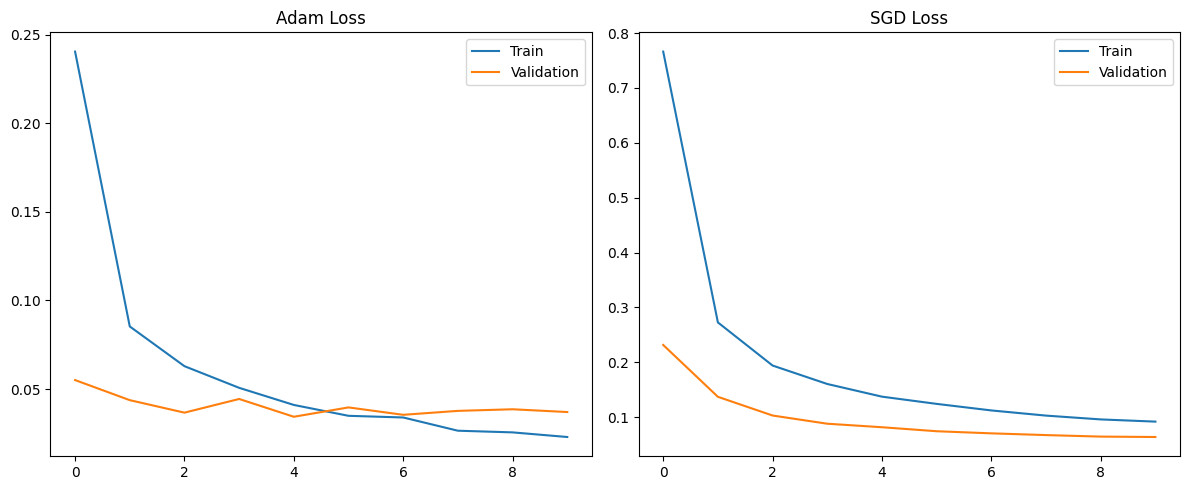

In [33]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_adam.history["loss"])
plt.plot(history_adam.history["val_loss"])

plt.title("Adam Loss")
plt.legend(["Train", "Validation"])


plt.subplot(1, 2, 2)
plt.plot(history_sgd.history["loss"])
plt.plot(history_sgd.history["val_loss"])

plt.title("SGD Loss")
plt.legend(["Train", "Validation"])
plt.tight_layout()
plt.show()

### Adam Accuracy & SGD Accuracy


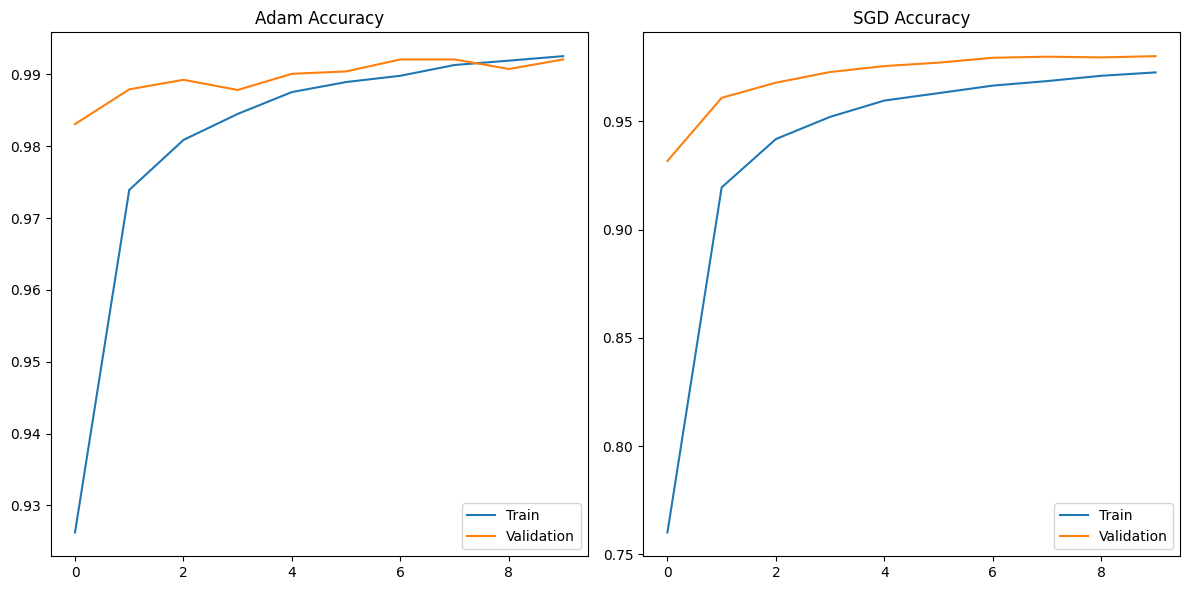

In [29]:
plt.figure(figsize=(12, 6))  # غير الأرقام زي ما تحب

plt.subplot(1, 2, 1)
plt.plot(history_adam.history["accuracy"])
plt.plot(history_adam.history["val_accuracy"])
plt.title("Adam Accuracy")
plt.legend(["Train", "Validation"])

plt.subplot(1, 2, 2)
plt.plot(history_sgd.history["accuracy"])
plt.plot(history_sgd.history["val_accuracy"])
plt.title("SGD Accuracy")
plt.legend(["Train", "Validation"])

plt.tight_layout()
plt.show()

# Final Comparison Table


In [18]:
print("===================================")
print("Final Comparison")
print("===================================")

print(f"Adam Accuracy : {adam_acc*100:.2f}%")
print(f"Adam Loss     : {adam_loss:.4f}")

print("-----------------------------------")

print(f"SGD Accuracy  : {sgd_acc*100:.2f}%")
print(f"SGD Loss      : {sgd_loss:.4f}")

Final Comparison
Adam Accuracy : 99.22%
Adam Loss     : 0.0279
-----------------------------------
SGD Accuracy  : 98.31%
SGD Loss      : 0.0525
